# Tema 2: Errores cuánticos

En este notebook vamos a explorar el tema de la corrección de errores cuánticos.

Los qubits son extremadamente susceptibles a errores debido a varios factores:

1. **Decoherencia**: La interacción del sistema cuántico con su entorno causa la pérdida de coherencia cuántica, destruyendo la superposición y el entrelazamiento.

2. **Ruido cuántico**: Fluctuaciones en los campos electromagnéticos, vibraciones térmicas y otras perturbaciones pueden alterar el estado de los qubits.

3. **Errores de puerta**: Las operaciones cuánticas nunca son perfectas y pueden introducir pequeños errores que se acumulan.

Por estas razones, es fundamental desarrollar técnicas de corrección de errores cuánticos (QEC - Quantum Error Correction) para proteger la información cuántica durante el procesamiento.

En este notebook exploraremos algunos de los códigos de corrección de errores más básicos:

- **Corrección de bitflip (bit-flip)**: Protege contra errores de tipo X (inversión del estado $|0\rangle \leftrightarrow |1\rangle$), análogo al error clásico de cambio de bit.

- **Corrección de phaseflip (phase-flip)**: Protege contra errores de tipo Z (cambio de fase relativa entre $|0\rangle$ y $|1\rangle$).

Estos códigos utilizan redundancia cuántica, codificando un qubit lógico en múltiples qubits físicos, lo que permite detectar y corregir errores sin medir directamente el estado cuántico (lo cual lo destruiría). Aunque son códigos simples que solo protegen contra un tipo de error cada uno, nos permitirán comprender los principios fundamentales de la corrección de errores cuánticos.

## Librerías

In [21]:
# %matplotlib widget
from quantum_circuit_drawer import DrawConfig, OutputOptions, draw_quantum_circuit
from quantum_circuit_drawer import draw_quantum_circuit as _draw_qc

draw_quantum_circuit = lambda x: _draw_qc(x, config=DrawConfig(output=OutputOptions(show=False)))

from quantum_circuit_drawer import plot_histogram as _plt_hist

def plot_histogram(*x):
    _plt_hist(*x)

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

from qiskit_aer import AerSimulator
# from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
import numpy as np

---
# Corrección de bitflip

Vamos a empezar creando el circuito cuántico para corregir el bitflip de un qubit. 

El código de corrección de bitflip funciona codificando un qubit lógico en tres qubits físicos. La idea es que si uno de los tres qubits sufre un error de tipo X (bitflip), podemos detectarlo comparando los tres qubits entre sí y corregirlo.

El circuito que vamos a implementar tiene las siguientes etapas:

1. **Inicialización**: Preparamos el qubit en el estado que queremos proteger (puede ser cualquier estado $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$).

2. **Codificación**: Copiamos la información del qubit original a dos qubits adicionales usando puertas CNOT, creando el estado codificado.

3. **Introducción de error**: Para probar el código, introduciremos intencionalmente un error de bitflip en uno de los qubits (esto es opcional y controlado por el parámetro `error`).

4. **Detección**: Usamos qubits ancilla para comparar los tres qubits y detectar cuál (si alguno) ha sufrido un error.

5. **Corrección**: Basándonos en las mediciones de los ancillas, aplicamos la corrección necesaria.

6. **Decodificación**: Revertimos la codificación para recuperar el qubit original, ahora corregido.

El diagrama a continuación muestra la estructura completa del circuito:

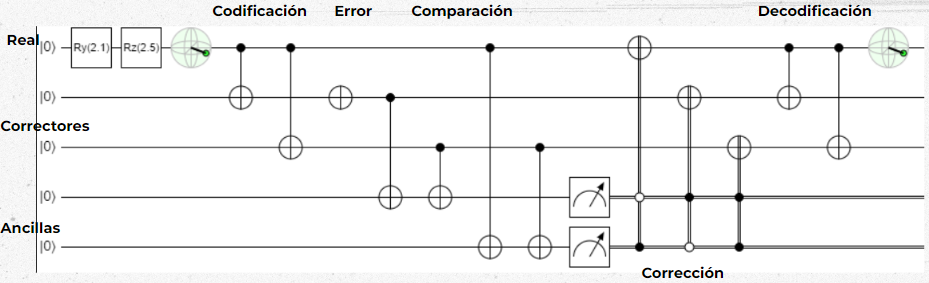

In [22]:
def bitflip(state: np.array, error:bool=True):
    #Registros
    qubit = QuantumRegister(1, 'q')
    qcomp = QuantumRegister(2, 'qc')
    anc   = QuantumRegister(2, 'anc')

    cr    = ClassicalRegister(2, 'c')

    qc    = QuantumCircuit(qubit, qcomp, anc, cr, name='Correction Bitflip')

    #Puertas
    #Estado
    qc.initialize(state, qubit[0])
    qc.barrier()
    #Codificación
    qc.cx([qubit[0],qubit[0]],qcomp[:])
    #Error
    if error:
        qc.x(qubit[0])
    #Comparación
    qc.cx(qcomp[:]+[qubit[0],qcomp[1]], [anc[0],anc[0],anc[1],anc[1]])
    qc.measure(anc[:],cr[:])

    #Corrección
    with qc.if_test((cr[0], 0)):
        with qc.if_test((cr[1], 1)):
            qc.x(qubit[0])
    with qc.if_test((cr[0], 1)):
        with qc.if_test((cr[1], 0)) as else_:
            qc.x(qcomp[0])
        with else_:
            qc.x(qcomp[1])

    #Decodificación
    qc.cx([qubit[0],qubit[0]],qcomp[:])

    return qc

Inicializamos el estado que queremos.

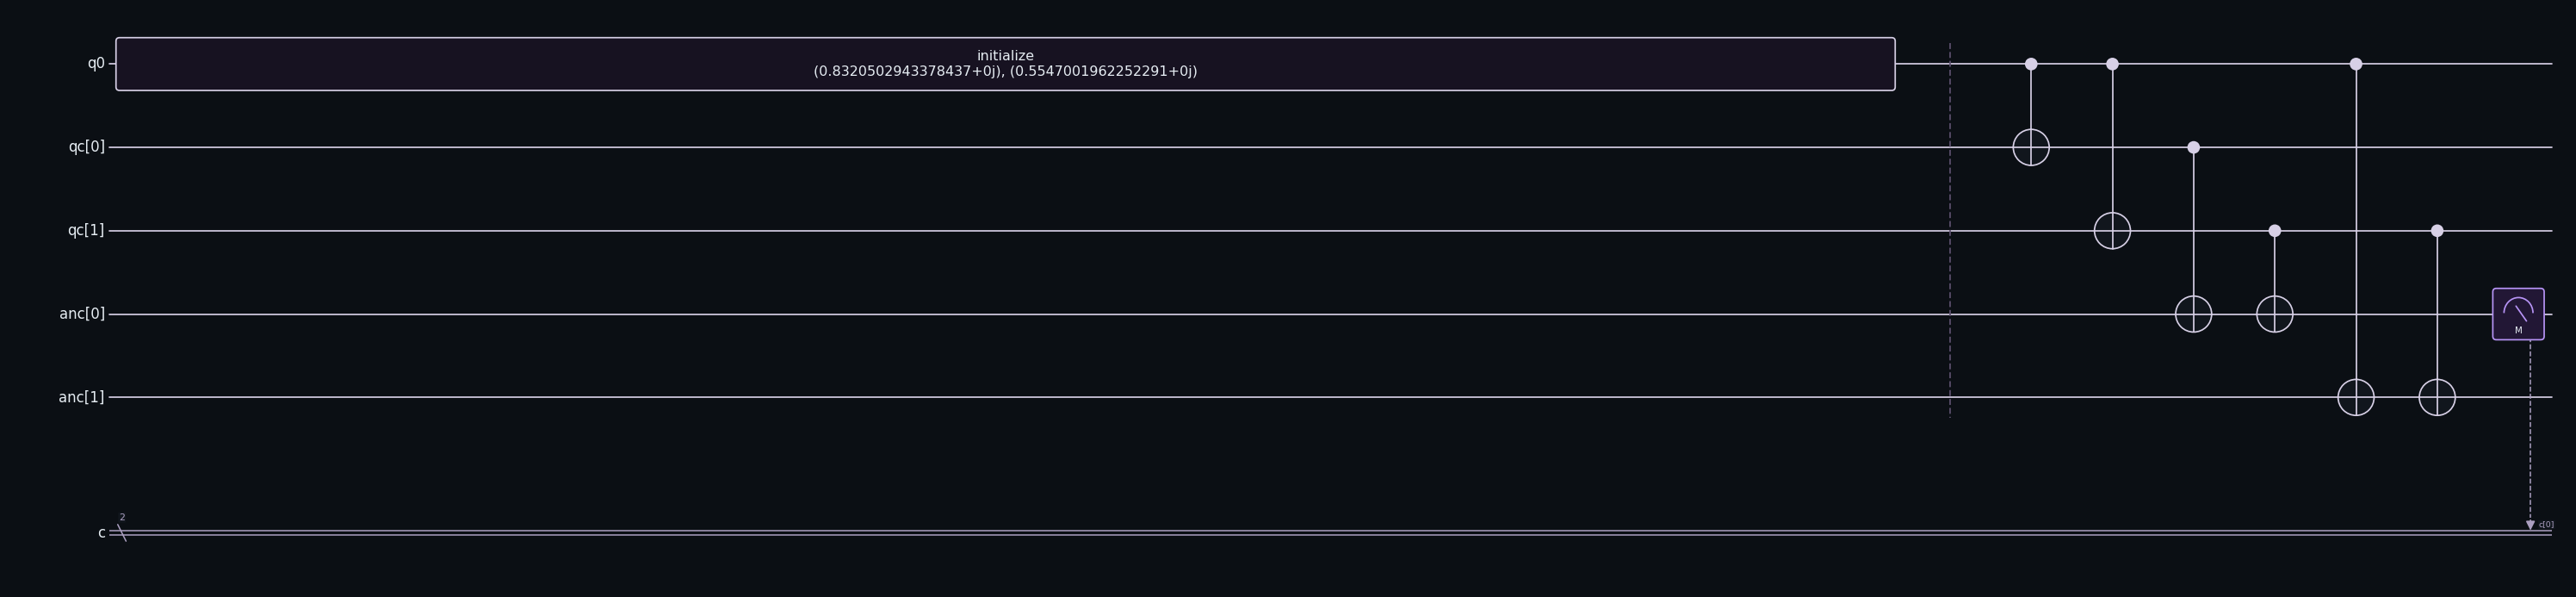

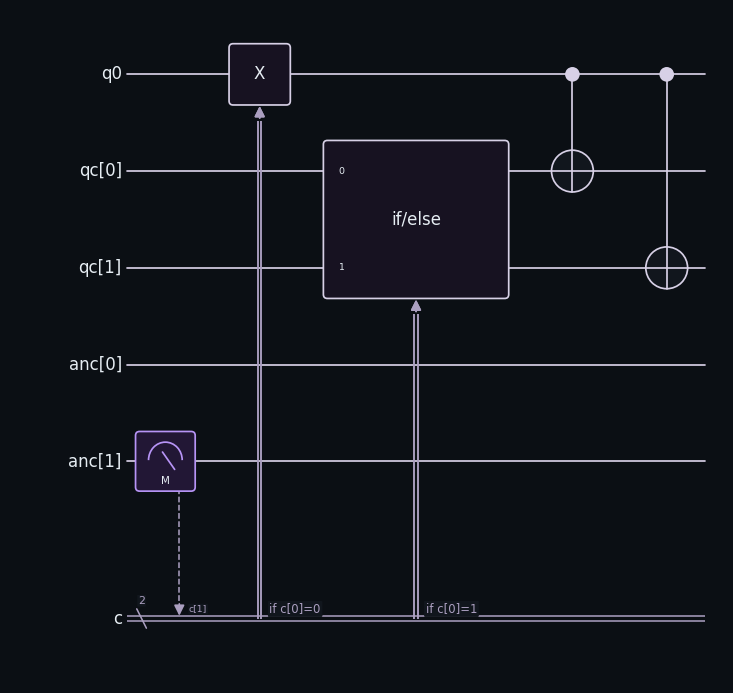

In [23]:
#Vector de estado
state = np.array([0.75, 0.5])
state /= np.sqrt(sum(state**2))
qc = bitflip(state, False)
# qc.draw('mpl')
draw_quantum_circuit(qc)

Añadimos la medición para comprobar.

In [24]:
crextra = ClassicalRegister(1, 's')
qc.add_register(crextra)
qc.measure(0,crextra[0])

Ejecutamos en simulador

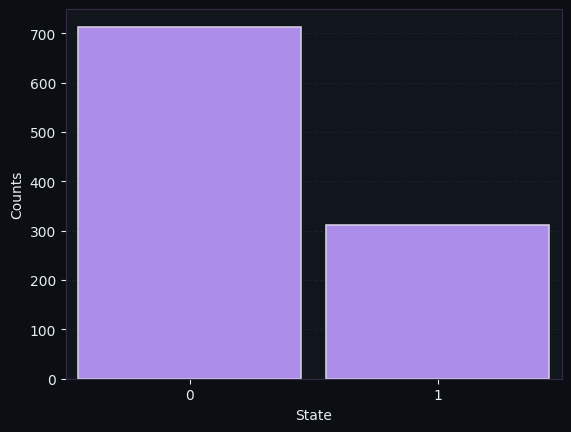

In [25]:
#Backend
backend = AerSimulator()
qc_transpiled = transpile(qc, backend)

#Creamos el job
job = backend.run(qc_transpiled)
result = job.result()

# Indicamos cual es el registro de interes
indices = [2]

result_marginal = marginal_counts(result, indices=indices)
marginal_counts_value = result_marginal.get_counts()

plot_histogram(marginal_counts_value)

In [26]:
state**2

array([0.69230769, 0.30769231])

Vemos que funciona bien sin error.

Ahora probemos con error.

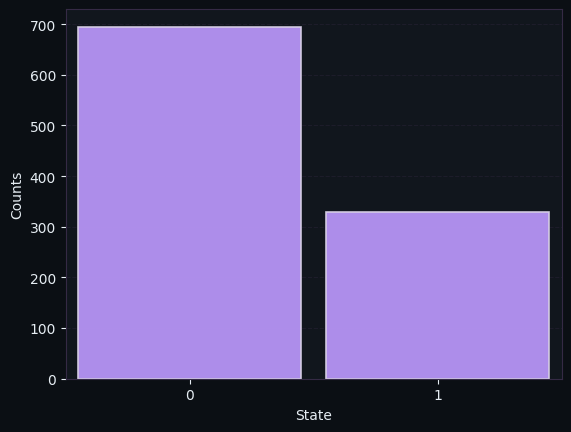

In [27]:
#Vector de estado
state = np.array([0.75, 0.5])
state /= np.sqrt(sum(state**2))
qc = bitflip(state, True)

crextra = ClassicalRegister(1, 's')
qc.add_register(crextra)
qc.measure(0,crextra[0])

#Backend
backend = AerSimulator()
qc_transpiled = transpile(qc, backend)

#Creamos el job
job = backend.run(qc_transpiled)
result = job.result()

# Indicamos cual es el registro de interes
indices = [2]

result_marginal = marginal_counts(result, indices=indices)
marginal_counts_value = result_marginal.get_counts()

plot_histogram(marginal_counts_value)

Corrige bien con error.

---
# Corrección de fase

Vamos a implementar la **corrección de fase**.

La corrección de fase es análoga a la corrección de bit-flip, pero en lugar de proteger contra errores de inversión de bit (**X**), protege contra errores de fase (**Z**). Para ello, utilizamos la base de Hadamard, aplicando puertas **H** antes y después de la codificación para transformar errores de fase en errores de bit, que luego podemos detectar y corregir de manera similar.

**El proceso consiste en:**
1. Codificar el estado cuántico en tres qubits mediante puertas **CNOT**
2. Aplicar puertas **Hadamard** para cambiar a la base X
3. Introducir el error de fase (si existe)
4. Volver a aplicar **Hadamard** para regresar a la base computacional
5. Comparar los qubits usando ancillas para detectar discrepancias
6. Aplicar correcciones según los resultados de las mediciones
7. Decodificar el estado protegido

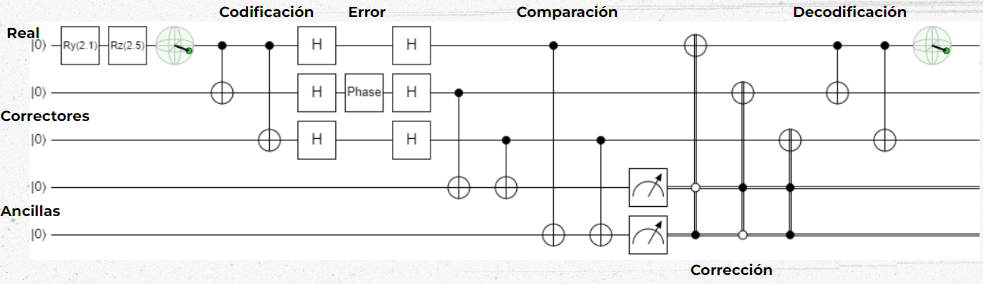

In [28]:
def phase(state: np.array, fase:float=0):
    #Registros
    qubit = QuantumRegister(1, 'q')
    qcomp = QuantumRegister(2, 'qc')
    anc   = QuantumRegister(2, 'anc')

    cr    = ClassicalRegister(2, 'c')

    qc    = QuantumCircuit(qubit, qcomp, anc, cr, name='Correction Phase')

    #Puertas
    #Estado
    qc.initialize(state, qubit[0])
    qc.barrier()
    #Codificación
    qc.cx([qubit[0],qubit[0]],qcomp[:])
    qc.h(qubit[:]+qcomp[:])
    #Error
    qc.p(fase,0)
    #Comparación
    qc.h(qubit[:]+qcomp[:])
    qc.cx(qcomp[:]+[qubit[0],qcomp[1]], [anc[0],anc[0],anc[1],anc[1]])
    qc.measure(anc[:],cr[:])

    #Corrección
    with qc.if_test((cr[0], 0)):
        with qc.if_test((cr[1], 1)):
            qc.x(qubit[0])
    with qc.if_test((cr[0], 1)):
        with qc.if_test((cr[1], 0)) as else_:
            qc.x(qcomp[0])
        with else_:
            qc.x(qcomp[1])

    #Decodificación
    qc.cx([qubit[0],qubit[0]],qcomp[:])

    return qc

Ejecutamos añadiendo una H para ver si corregimos bien.

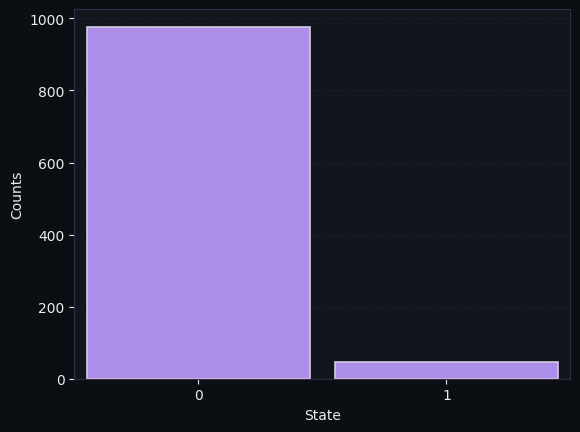

In [29]:
#Vector de estado
state = np.array([0.75, 0.5])
state /= np.sqrt(sum(state**2))
fase = 2

qc = phase(state, fase)

qc.h(0)

#Ponemos esto para comprobar
crextra = ClassicalRegister(1, 's')
qc.add_register(crextra)
qc.measure(0,crextra[0])

#Backend
backend = AerSimulator()
qc_transpiled = transpile(qc, backend)

#Creamos el job
job = backend.run(qc_transpiled)
result = job.result()

# Indicamos cual es el registro de interes
indices = [2]

result_marginal = marginal_counts(result, indices=indices)
marginal_counts_value = result_marginal.get_counts()

plot_histogram(marginal_counts_value)

Vamos a probar a hacerlo clásicamente.

In [30]:
H = np.array([[1,1],[1,-1]])/np.sqrt(2)

(H @ state)**2

array([0.96153846, 0.03846154])

Corrige bien.